In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
T=pd.read_csv('peanut_clean_contingencies_only_parsed_data.csv')

In [58]:
T_short=T[600:1200]
T_short

,Unnamed: 0,leaf,stem,reward,contingency,date,session,trial
600,600,6,C,1,502050802080,20201125,1,60
601,601,5,C,1,502050802080,20201125,1,61
602,602,6,C,1,502050802080,20201125,1,62
603,603,5,C,0,502050802080,20201125,1,63
604,604,3,B,1,502050802080,20201125,1,64
...,...,...,...,...,...,...,...,...
1195,1195,4,B,0,208080502050,20201125,4,115
1196,1196,3,B,1,208080502050,20201125,4,116
1197,1197,4,B,1,208080502050,20201125,4,117
1198,1198,3,B,0,208080502050,20201125,4,118


In [108]:
choice=np.array(T_short['leaf'])
reward=np.array(T_short['reward'])

In [73]:
X=np.zeros((len(choice),6))
for i in range(6):
    X[choice==i+1,i]=1

In [74]:
X

array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       ...,
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.]])

In [34]:
contingency=np.array(T['contingency'])

### set up HMM model

In [36]:
from hmmlearn.hmm import MultinomialHMM

In [157]:
hmm_model=MultinomialHMM(n_components=6,algorithm='map')  

In [158]:
# startprob
startprob = np.ones(6)/6

In [159]:
startprob

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [160]:
# transmat
v=1-1/60   #volatiliy
transmat = np.ones((6,6))*(1-v)/5
np.fill_diagonal(transmat,v)

In [161]:
transmat

array([[0.98333333, 0.00333333, 0.00333333, 0.00333333, 0.00333333,
        0.00333333],
       [0.00333333, 0.98333333, 0.00333333, 0.00333333, 0.00333333,
        0.00333333],
       [0.00333333, 0.00333333, 0.98333333, 0.00333333, 0.00333333,
        0.00333333],
       [0.00333333, 0.00333333, 0.00333333, 0.98333333, 0.00333333,
        0.00333333],
       [0.00333333, 0.00333333, 0.00333333, 0.00333333, 0.98333333,
        0.00333333],
       [0.00333333, 0.00333333, 0.00333333, 0.00333333, 0.00333333,
        0.98333333]])

In [162]:
# emissionprob
emissionprob=np.ones((6,6))*0.2
np.fill_diagonal(emissionprob,0.8)

In [163]:
emissionprob

array([[0.8, 0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.8, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.8, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.8, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.8, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2, 0.8]])

In [164]:
emissionprob=np.hstack((np.ones((6,1))*0.2,emissionprob))

In [165]:
#emissionprob=np.vstack((np.array([[1,0,0,0,0,0,0]]),emissionprob))

In [166]:
emissionprob

array([[0.2, 0.8, 0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.8, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.8, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.8, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2, 0.8, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.8]])

In [167]:
hmm_model.startprob_ = startprob
hmm_model.transmat_ = transmat
hmm_model.emissionprob_=emissionprob

### fit data

In [168]:
observations=np.atleast_2d(choice*reward).T

In [169]:
P=hmm_model.predict_proba(observations)

960
508080202050


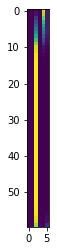

In [187]:
b=7
print(60*(b-1)+600)
plt.imshow(P[60*(b-1):60*b,:])
print(np.array(T_short['contingency'])[60*(b-1)])

In [83]:
T_short['contingency'][60*]

600     502050802080
601     502050802080
602     502050802080
603     502050802080
604     502050802080
            ...     
1195    208080502050
1196    208080502050
1197    208080502050
1198    208080502050
1199    208080502050
Name: contingency, Length: 600, dtype: int64